# Reinforcement Learning Individual Assignment
## Text Flappy Bird — SARSA(λ) Agent with Eligibility Traces

In [1]:
import os, sys
import gymnasium as gym
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import pickle
from pathlib import Path

import text_flappy_bird_gym

## 1. Environment Setup

We use `TextFlappyBird-v0` which returns `(x_distance, y_distance)` as the state. The action space is `Discrete(2)`: **0 = idle**, **1 = flap**.

In [2]:
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)

obs, info = env.reset()
print(f"Observation: {obs}")
print(f"Action space: {env.action_space}")  # Discrete(2)

Observation: (13, -2)
Action space: Discrete(2)


## 2. SARSA(λ) Agent

SARSA(λ) extends the one-step SARSA update with **eligibility traces**, which propagate the TD error backwards to all recently visited state-action pairs in a single pass.

**Key parameters:**
- $\alpha$ — step-size (learning rate)
- $\gamma$ — discount factor
- $\lambda$ — trace-decay parameter ($\lambda = 0$ gives one-step SARSA; $\lambda = 1$ gives Monte-Carlo-like behaviour)
- $\epsilon$ — exploration rate, decayed via GLIE: $\epsilon = 1/k$

**Per-step update (accumulating traces):**

$$\delta_t = R_{t+1} + \gamma \, Q(S', A') - Q(S, A)$$
$$E(S, A) \leftarrow E(S, A) + 1$$
$$\forall (s,a): \quad Q(s,a) \leftarrow Q(s,a) + \alpha \, \delta_t \, E(s,a)$$
$$\forall (s,a): \quad E(s,a) \leftarrow \gamma \, \lambda \, E(s,a)$$

In [ ]:
class SarsaLambdaAgent:
    """SARSA(lambda) agent with accumulating eligibility traces for Text Flappy Bird."""

    def __init__(
        self,
        n_actions: int = 2,
        alpha: float = 0.1,
        gamma: float = 1.0,
        lambd: float = 0.8,
        min_epsilon: float = 0.01,
    ):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.lambd = lambd
        self.min_epsilon = min_epsilon

        self.Q = defaultdict(float)   # (state, action) -> value
        self.epsilon = 1.0
        self.episode_count = 0

    # policy
    def get_action(self, state: tuple) -> int:
        """ε-greedy action selection."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best)

    def greedy_action(self, state: tuple) -> int:
        """Purely greedy action (for evaluation)."""
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best)

    # learning (one full episode)
    def run_episode(self, env) -> float:
        """
        Play one episode with SARSA(lambda) updates (accumulating traces).

        Returns the total undiscounted reward collected in the episode.
        """
        # Reset eligibility traces at the start of every episode
        E = defaultdict(float)

        obs, _ = env.reset()
        S = tuple(obs)
        A = self.get_action(S)
        total_reward = 0.0

        done = False
        while not done:
            obs_next, reward, done, _, info = env.step(A)
            total_reward += reward
            S_next = tuple(obs_next)

            if done:
                # Terminal step: Q(terminal, ·) = 0, so TD target is just R
                delta = reward - self.Q[(S, A)]
            else:
                A_next = self.get_action(S_next)
                delta = reward + self.gamma * self.Q[(S_next, A_next)] - self.Q[(S, A)]

            # Accumulating trace for the current (S, A)
            E[(S, A)] += 1.0

            # Update all Q-values that have non-zero traces
            for sa in list(E.keys()):
                self.Q[sa] += self.alpha * delta * E[sa]
                E[sa] *= self.gamma * self.lambd
                # Remove negligible traces to keep the dict small
                if E[sa] < 1e-6:
                    del E[sa]

            if not done:
                S = S_next
                A = A_next

        return total_reward

    # epsilon decay
    def decay_epsilon(self):
        """GLIE epsilon decay: epsilon = 1/k, floored at min_epsilon."""
        self.episode_count += 1
        self.epsilon = max(self.min_epsilon, 1.0 / self.episode_count)

## 3. Training Loop

Each episode:
1. Run a full episode with online SARSA(λ) updates (eligibility traces propagate the TD error to all recently visited state-action pairs).
2. Decay $\epsilon \leftarrow 1/k$ (GLIE).

In [ ]:
def train(env, agent, n_episodes: int = 50_000, log_every: int = 1000):
    """Train the SARSA(lambda) agent and return training statistics."""
    reward_history = []
    avg_rewards = []
    epsilon_history = []

    for k in tqdm(range(1, n_episodes + 1), desc="Training SARSA(\u03BB)"):
        total_reward = agent.run_episode(env)
        agent.decay_epsilon()

        reward_history.append(total_reward)
        epsilon_history.append(agent.epsilon)

        if k % log_every == 0:
            avg_r = np.mean(reward_history[-log_every:])
            avg_rewards.append(avg_r)
            print(f"Episode {k:>7d} | Avg reward (last {log_every}): {avg_r:7.2f} "
                  f"| \u03B5: {agent.epsilon:.5f} | Q-table size: {len(agent.Q)}")

    return reward_history, avg_rewards, epsilon_history

In [ ]:
# Hyperparameters
ALPHA = 0.1         # step-size
GAMMA = 1.0         # discount factor (undiscounted, episodic)
LAMBDA = 0.8        # trace-decay
MIN_EPS = 0.01      # epsilon floor
N_EPISODES = 50_000 # number of training episodes

# Create agent
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
agent = SarsaLambdaAgent(
    n_actions=env.action_space.n,
    alpha=ALPHA,
    gamma=GAMMA,
    lambd=LAMBDA,
    min_epsilon=MIN_EPS,
)

TRAIN_AGENT = False
SAVE_AGENT = True

In [ ]:
results_dir = Path.cwd().parent / 'results' / 'SARSA'
results_dir.mkdir(parents=True, exist_ok=True)
save_path = results_dir / 'sarsa_lambda_agent.pkl'

# Train or load agent
if TRAIN_AGENT:
    reward_history, avg_rewards, epsilon_history = train(env, agent, n_episodes=N_EPISODES)

    # Save
    if SAVE_AGENT:
        with open(save_path, 'wb') as f:
            pickle.dump({
                'Q': dict(agent.Q),
                'epsilon': agent.epsilon,
                'episode_count': agent.episode_count,
                'alpha': agent.alpha,
                'gamma': agent.gamma,
                'lambd': agent.lambd,
            }, f)
        print(f"Agent saved to {save_path}")
else:
    # Load the trained agent
    if save_path.exists():
        with open(save_path, 'rb') as f:
            data = pickle.load(f)
            agent.Q = defaultdict(float, data['Q'])
            agent.epsilon = data['epsilon']
            agent.episode_count = data['episode_count']
            agent.alpha = data['alpha']
            agent.gamma = data['gamma']
            agent.lambd = data['lambd']
        print(f"Agent loaded from {save_path}")
    else:
        print(f"No saved agent found at {save_path}. Please train the agent first.")

Training SARSA(λ):   3%|▎         | 1413/50000 [00:00<00:17, 2750.51it/s]

Episode    1000 | Avg reward (last 1000):    8.90 | ε: 0.01000 | Q-table size: 273


Training SARSA(λ):   5%|▍         | 2354/50000 [00:00<00:16, 2918.40it/s]

Episode    2000 | Avg reward (last 1000):    8.88 | ε: 0.01000 | Q-table size: 331


Training SARSA(λ):   7%|▋         | 3558/50000 [00:01<00:16, 2786.35it/s]

...

Episode   48000 | Avg reward (last 1000):  531.37 | ε: 0.01000 | Q-table size: 540


Training SARSA(λ):  98%|█████████▊| 49007/50000 [20:11<00:39, 25.28it/s]

Episode   49000 | Avg reward (last 1000):  670.08 | ε: 0.01000 | Q-table size: 540


Training SARSA(λ): 100%|██████████| 50000/50000 [21:05<00:00, 39.52it/s]

Episode   50000 | Avg reward (last 1000):  750.15 | ε: 0.01000 | Q-table size: 540


## 4. Training Curves

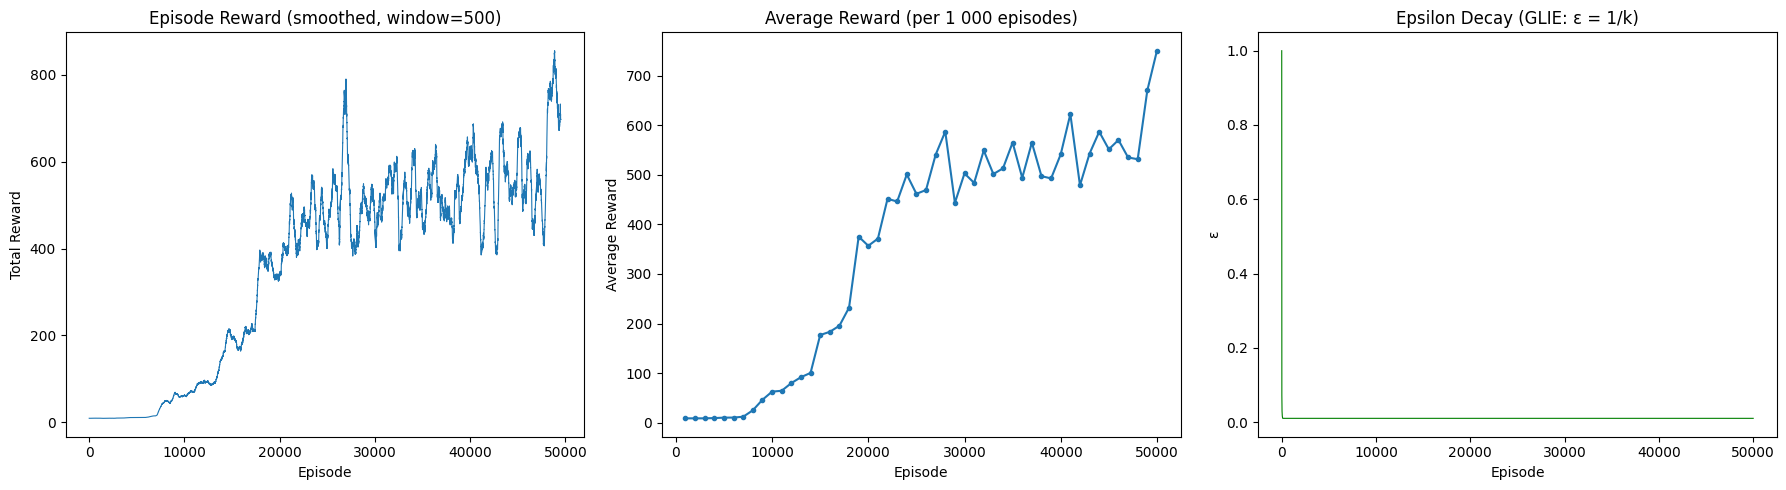

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Smoothed episode reward
window = 500
smoothed = np.convolve(reward_history, np.ones(window) / window, mode='valid')
axes[0].plot(smoothed, linewidth=0.8)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title(f'Episode Reward (smoothed, window={window})')

# Average reward per logging interval
axes[1].plot(range(1000, N_EPISODES + 1, 1000), avg_rewards, marker='o', markersize=3)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Average Reward')
axes[1].set_title('Average Reward (per 1 000 episodes)')

# Epsilon decay
axes[2].plot(epsilon_history, linewidth=0.8, color='green')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('\u03B5')
axes[2].set_title('Epsilon Decay (GLIE: \u03B5 = 1/k)')

plt.tight_layout()
plt.show()

## 5. Evaluation (Greedy Policy)

Run the trained agent greedily ($\epsilon = 0$) over many episodes to measure its performance.

Greedy evaluation over 1 000 episodes:
  Mean reward : 6056.08
  Std reward  : 5977.80
  Max reward  : 43148
  Min reward  : 28


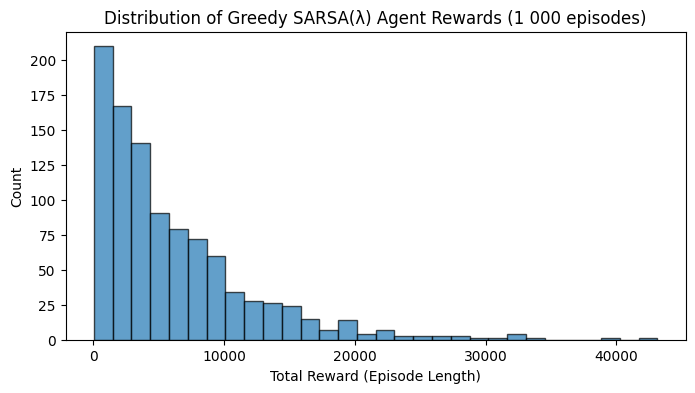

In [ ]:
def evaluate(env, agent, n_episodes: int = 1000):
    """Evaluate the agent using a purely greedy policy (no exploration)."""
    total_rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        state = tuple(obs)
        total_reward = 0.0
        done = False
        while not done:
            action = agent.greedy_action(state)
            obs, reward, done, _, info = env.step(action)
            state = tuple(obs)
            total_reward += reward
        total_rewards.append(total_reward)
    return total_rewards

eval_rewards = evaluate(env, agent, n_episodes=1000)
print(f"Greedy evaluation over 1 000 episodes:")
print(f"  Mean reward : {np.mean(eval_rewards):.2f}")
print(f"  Std reward  : {np.std(eval_rewards):.2f}")
print(f"  Max reward  : {np.max(eval_rewards):.0f}")
print(f"  Min reward  : {np.min(eval_rewards):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(eval_rewards, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Total Reward (Episode Length)')
plt.ylabel('Count')
plt.title('Distribution of Greedy SARSA(\u03BB) Agent Rewards (1 000 episodes)')
plt.show()

## 6. Live Demo
Run the trained agent with the screen variant and watch it play in real-time using the scripts/SARSAAgent.py script.

In [9]:
# Play one episode with the screen renderer
demo_env = gym.make('TextFlappyBird-screen-v0', height=15, width=20, pipe_gap=4)
state_env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)

obs_screen, _ = demo_env.reset()
obs_state, _ = state_env.reset()

done = False
total_reward = 0

while not done:
    state = tuple(obs_state)
    action = agent.greedy_action(state)

    obs_screen, reward, done, _, info = demo_env.step(action)
    obs_state, _, _, _, _ = state_env.step(action)
    total_reward += reward

    os.system("cls" if os.name == "nt" else "clear")
    sys.stdout.write(demo_env.render())
    time.sleep(0.15)

print(f"\nGame Over — Total Reward: {total_reward}")
demo_env.close()
state_env.close()

Text Flappy Bird!
Score: 0
----------------------
[                  | ]
[                  | ]
[                  | ]
[                    ]
[                    ]
[                    ]
[                    ]
[      @           | ]
[                  | ]
[                  | ]
[                  | ]
[                  | ]
[                  | ]
[                  | ]
[                  | ]
^^^^^^^^^^^^^^^^^^^^^^
(Idle)
Text Flappy Bird!
Score: 0
----------------------
[                 |  ]
[                 |  ]
[                 |  ]
[                    ]
[                    ]
[                    ]
[      @             ]
[                 |  ]
[                 |  ]
[                 |  ]
[                 |  ]
[                 |  ]
[                 |  ]
[                 |  ]
[                 |  ]
^^^^^^^^^^^^^^^^^^^^^^
(Flap)
Text Flappy Bird!
Score: 0
----------------------
[                |   ]
[                |   ]
[                |   ]
[                    ]
[       